In [1]:
#!pip install roboflow

#from roboflow import Roboflow
#rf = Roboflow(api_key="Os0LrSFQLDcLOoBna47Q")
#project = rf.workspace("indys-workspace").project("deteksi-cacat-permukaan-jeruk")
#version = project.version(4)
#dataset = version.download("yolo26")
                

# PERUBAHAN MULAI DARI SINI

In [2]:
!pip install -q -U ultralytics roboflow pyyaml #baru
import torch

print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.0 MB/s eta 0:00:00
Torch version: 2.10.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: Tesla T4


In [3]:
from roboflow import Roboflow #baru
from pathlib import Path

rf = Roboflow(api_key="Os0LrSFQLDcLOoBna47Q")

project = rf.workspace("indys-workspace").project("deteksi-cacat-permukaan-jeruk")
version = project.version(4)

dataset = version.download("yolo26")

dataset_path = Path(dataset.location)
yaml_path = dataset_path / "data.yaml"

print("Dataset path:", dataset_path)
print("YAML path:", yaml_path)
print(yaml_path.read_text())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteksi-Cacat-Permukaan-Jeruk-4 in yolo26:: 100%|██████████| 5541/5541 [00:00<00:00, 11972.53it/s]

Dataset path: /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4
YAML path: /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Cacat', 'Normal']

roboflow:
  workspace: indys-workspace
  project: deteksi-cacat-permukaan-jeruk
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/indys-workspace/deteksi-cacat-permukaan-jeruk/dataset/4


In [4]:
# perbaiki file yaml
import yaml
from pathlib import Path

with open(yaml_path, "r") as f:
    old_yaml = yaml.safe_load(f)

train_img = dataset_path / "train" / "images"
val_img = dataset_path / "valid" / "images"
test_img = dataset_path / "test" / "images"

if not train_img.exists():
    raise FileNotFoundError(f"Folder train/images tidak ditemukan: {train_img}")

if not val_img.exists():
    raise FileNotFoundError(f"Folder valid/images tidak ditemukan: {val_img}")

if not test_img.exists():
    .32
    print("Folder test/images tidak ditemukan. Test akan memakai valid/images.")
    test_img = val_img

data_fixed = {
    "train": str(train_img),
    "val": str(val_img),
    "test": str(test_img),
    "nc": old_yaml.get("nc", 2),
    "names": old_yaml.get("names", ["Cacat", "Normal"])
}

fixed_yaml_path = "/kaggle/working/data_fixed.yaml"

with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_fixed, f, sort_keys=False)

print("Isi data_fixed.yaml:")
print(open(fixed_yaml_path).read())

Isi data_fixed.yaml:
train: /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/train/images
val: /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/valid/images
test: /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images
nc: 2
names:
- Cacat
- Normal



In [5]:
# cek gambar dataset
from pathlib import Path 

print("Cek jumlah gambar dan label:")

for split in ["train", "valid", "test"]:
    img_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    if img_dir.exists():
        images = (
            list(img_dir.glob("*.jpg")) +
            list(img_dir.glob("*.jpeg")) +
            list(img_dir.glob("*.png"))
        )
        print(f"{split} images:", len(images))

    if label_dir.exists():
        labels = list(label_dir.glob("*.txt"))
        print(f"{split} labels:", len(labels))

Cek jumlah gambar dan label:
train images: 2076
train labels: 2076
valid images: 363
valid labels: 363
test images: 329
test labels: 329


In [6]:

from ultralytics import YOLO # baru
import torch
import os

os.environ["WANDB_DISABLED"] = "true"

device = 0 if torch.cuda.is_available() else "cpu"
print("Device digunakan:", device)

model = YOLO("yolo26n.yaml")

results = model.train(
    data=fixed_yaml_path,
    split="train",
    epochs=100,
    imgsz=640,
    batch=16 if torch.cuda.is_available() else 2,
    device=device,
    workers=2,
    project="/kaggle/working/yolo26_training",
    name="yolo26n_scratch_cacat_jeruk",
    pretrained=False,
    patience=15,
    plots=True,
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device digunakan: 0
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torc

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100      2.61G      1.753       3.23    0.02826         24        640: 100% ━━━━━━━━━━━━ 130/130 6.0it/s 21.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 7.6it/s 1.6s
                   all        363        363      0.494          1      0.593      0.405

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/100      2.61G      1.603      1.974    0.02525         29        640: 100% ━━━━━━━━━━━━ 130/130 6.1it/s 21.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 7.7it/s 1.6s
                   all        363        363      0.498      0.979      0.578      0.318

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/100      2.61G      1.556      1.547    0.02435         25        640: 100% ━━━━━━━━━━━━ 130/130 6.1it/s 21.2s
                 Class     Images  Instances      Box

In [7]:
# validasi model
best_model_path = "/kaggle/working/yolo26_training/yolo26n_scratch_cacat_jeruk/weights/best.pt"

best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=fixed_yaml_path,
    split="val",
    imgsz=640,
    batch=16,
    device=device,
    plots=True
)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 498.8±99.0 MB/s, size: 11.9 KB)
val: Scanning /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/valid/labels.cache... 363 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 363/363 138.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.1it/s 2.8s
                   all        363        363      0.868      0.937       0.96      0.936
                 Cacat        193        193      0.821      0.974      0.959      0.926
                Normal        170        170      0.916        0.9       0.96      0.947
Speed: 0.8ms preprocess, 2.5ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


In [8]:
# testing model
best_model.predict(
    source=str(test_img),
    imgsz=640,
    batch=16,
    conf=0.50,
    device=device,
    save=True,
    project="/kaggle/working/yolo26_prediction",
    name="prediction_result",
    exist_ok=True
)


image 1/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00000_jpg.rf.af7c2d53e28183eed13db9a2a711d4f1.jpg: 384x640 1 Normal, 2.7ms
image 2/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00001_jpg.rf.3e821f294f75f22e72ab38bde5690a41.jpg: 384x640 1 Normal, 2.7ms
image 3/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00001_jpg.rf.672bed5448ebaa86d8cf0c5664b73921.jpg: 384x640 1 Cacat, 2.7ms
image 4/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00003_jpg.rf.31c884205b4861a1361b6a67f84a2496.jpg: 384x640 1 Normal, 2.7ms
image 5/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00004_jpg.rf.057d4e77c984feb6fab3fc7b83fe7135.jpg: 384x640 1 Cacat, 2.7ms
image 6/329 /kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-4/test/images/conveyor_frame_00004_jpg.rf.21c415af344f3cbe856e9d782a9efb0a.jpg: 384x640 1 Cacat, 2.7ms
image 7/329 /kaggle/working/De

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Cacat', 1: 'Normal'}
 obb: None
 orig_img: array([[[213, 213, 213],
         [213, 213, 213],
         [213, 213, 213],
         ...,
         [174, 176, 176],
         [174, 176, 176],
         [173, 175, 175]],
 
        [[213, 213, 213],
         [213, 213, 213],
         [214, 214, 214],
         ...,
         [177, 179, 179],
         [176, 178, 178],
         [176, 178, 178]],
 
        [[213, 213, 213],
         [214, 214, 214],
         [214, 214, 214],
         ...,
         [180, 182, 182],
         [180, 182, 182],
         [180, 182, 182]],
 
        ...,
 
        [[191, 192, 190],
         [190, 191, 189],
         [190, 191, 189],
         ...,
         [186, 186, 186],
         [185, 185, 185],
         [185, 185, 185]],
 
        [[190, 191, 189],
         [189, 190, 188],
         [188, 189, 187],
       

Jumlah gambar hasil prediksi: 329


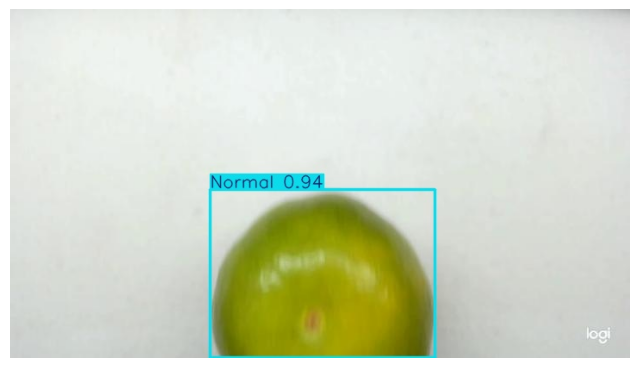

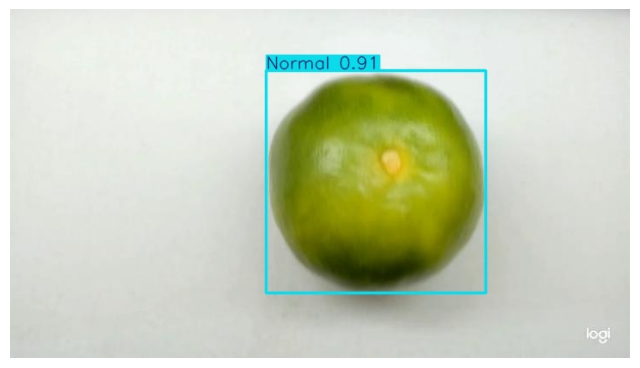

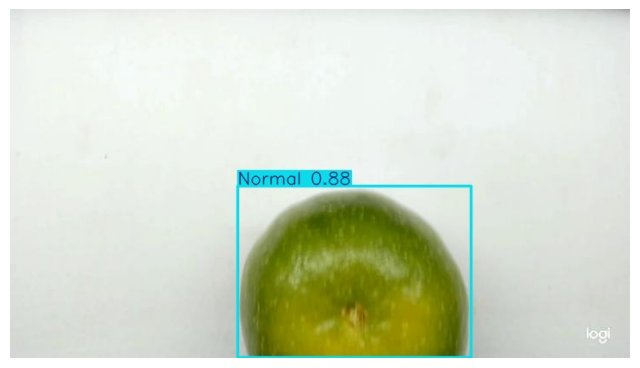

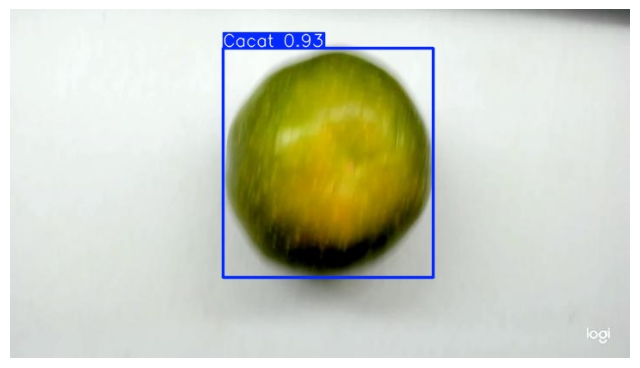

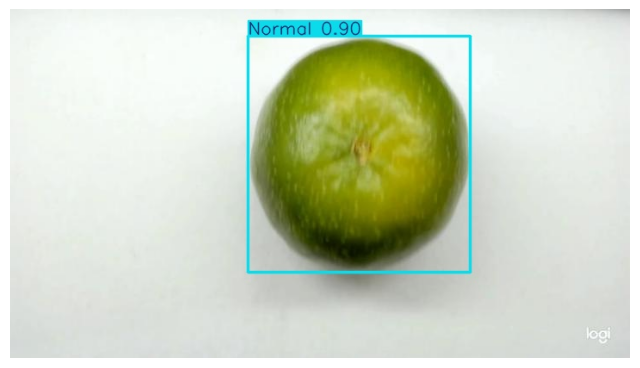

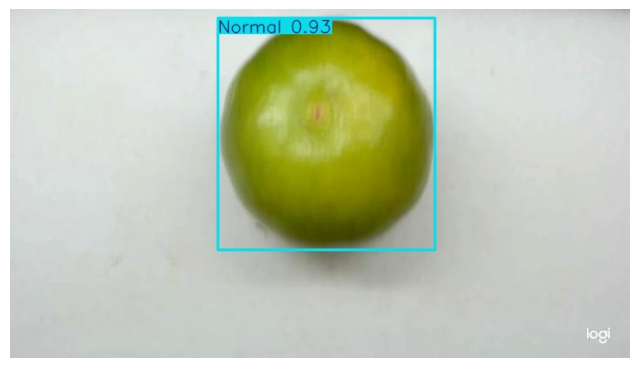

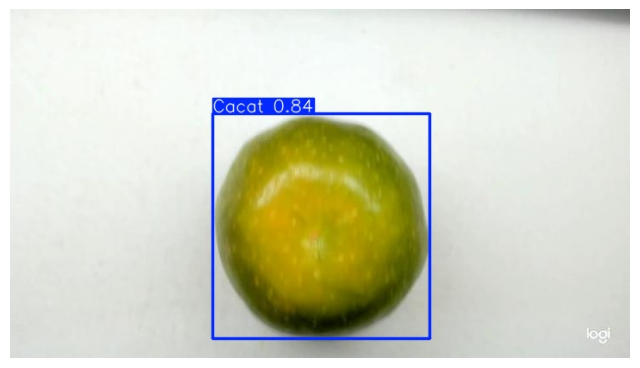

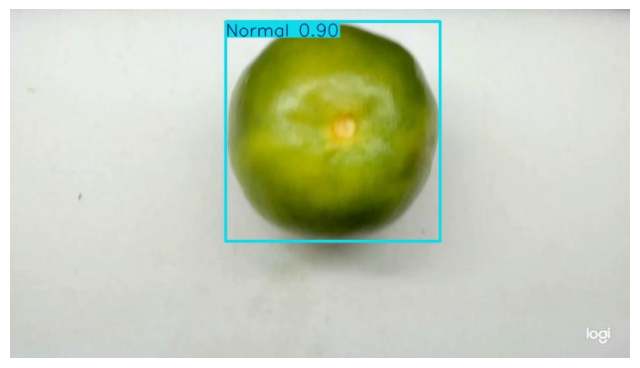

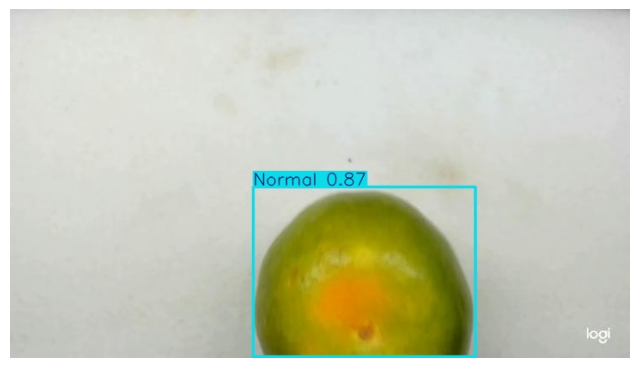

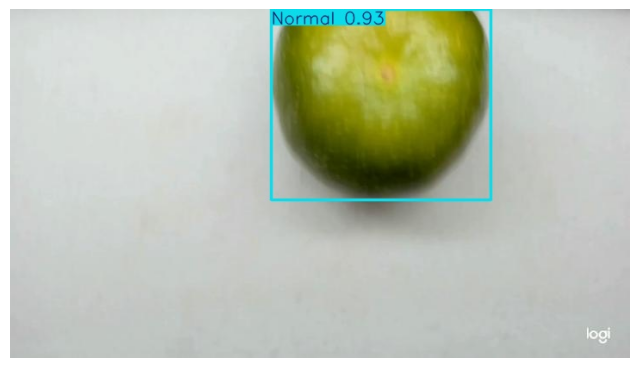

In [9]:
# tampilkan hasil prediksi
import glob
import cv2
import matplotlib.pyplot as plt

pred_folder = "/kaggle/working/yolo26_prediction/prediction_result"

pred_images = (
    glob.glob(pred_folder + "/*.jpg") +
    glob.glob(pred_folder + "/*.jpeg") +
    glob.glob(pred_folder + "/*.png")
)

print("Jumlah gambar hasil prediksi:", len(pred_images))

for img_path in pred_images[:10]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# PERUBAHAN SELESAI DI SINI

In [10]:
#!nvidia-smi

In [11]:
#!pip install -U ultralytics

#import ultralytics
#ultralytics.checks()

#from ultralytics import YOLO
#import os
#from pathlib import Path

In [12]:
#DATASET_PATH = "/kaggle/input/datasets/indyistiqamah/dataset-cacat-permukaan-v3"
#!ls {DATASET_PATH}

#yaml_path = "/kaggle/input/datasets/indyistiqamah/dataset-cacat-permukaan-v3/Deteksi Cacat Permukaan Jeruk.v3-test-1.yolo26/data.yaml"

In [13]:
#model = YOLO("yolo26n.yaml")

#results = model.train(
#    data=yaml_path,
#    epochs=50,
#    imgsz=640,
#    batch=16,
#    device=0,
#    workers=2,
#    project="/kaggle/working/yolo26_training",
#    name="yolo26n_citrus_public",
#    pretrained=True
#)

In [14]:
#!pip install -q -U ultralytics roboflow pyyaml

#import torch

#print("Torch version:", torch.__version__)
#print("CUDA available:", torch.cuda.is_available())
#print("CUDA device count:", torch.cuda.device_count())

#if torch.cuda.is_available():
#    print("GPU:", torch.cuda.get_device_name(0))
#    device = 0
#else:
#    print("GPU belum aktif. Aktifkan melalui Kaggle > Settings > Accelerator > GPU.")
#    device = "cpu"